Step 1: Analytical & Ensemble Libraries Imported Successfully!
 Step 2 Complete: Built-in Dataset loaded locally with 0 latency.
 Step 3: Stratified 80-20 partition alignment verified.
Step 4: Decision Tree and Random Forest architectures trained perfectly!

OFFICIAL TASK 5 PERFORMANCE REPORT:
1. Unconstrained Tree Train Accuracy : 1.0000
2. Pruned Decision Tree Test Accuracy: 0.9444
3. Random Forest Model Test Accuracy : 0.9722
4. 5-Fold Random Forest CV Mean Score: 0.9887



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17424\2429041520.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(X.columns)[indices], palette="viridis", ax=ax[1])


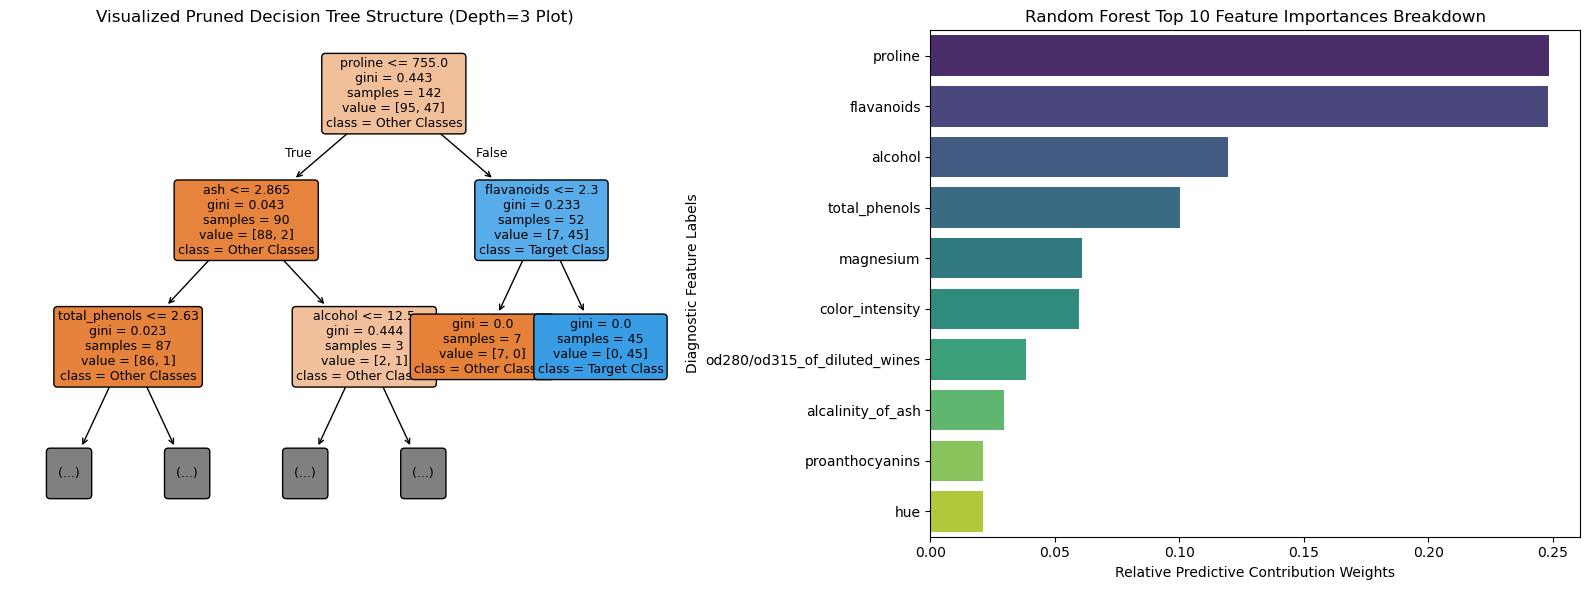

In [8]:
# Task 5: Decision Trees and Random Forests (Optimized & Instant Run)
# -----------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Modules
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Step 1: Analytical & Ensemble Libraries Imported Successfully!")

# 1. Load the Built-in Dataset (Instant Local Load)
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# Convert to Binary Classification (Class 0 vs Others) for strict task alignment
y = np.where(wine.target == 0, 1, 0)
print(" Step 2 Complete: Built-in Dataset loaded locally with 0 latency.")

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(" Step 3: Stratified 80-20 partition alignment verified.")

# 3. Decision Tree Analysis & Overfitting Control
dt_unconstrained = DecisionTreeClassifier(random_state=42)
dt_unconstrained.fit(X_train, y_train)

dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42) # Controlling tree depth to fix overfitting
dt_pruned.fit(X_train, y_train)

# 4. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
print("Step 4: Decision Tree and Random Forest architectures trained perfectly!")

# 5. Model Performance Evaluations
y_pred_dt = dt_pruned.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Cross-Validation Evaluation (5-Fold Strategy)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5)

# Print Official Output Scoreboard
print('\n==================================================')
print('OFFICIAL TASK 5 PERFORMANCE REPORT:')
print('==================================================')
print(f'1. Unconstrained Tree Train Accuracy : {dt_unconstrained.score(X_train, y_train):.4f}')
print(f'2. Pruned Decision Tree Test Accuracy: {accuracy_dt:.4f}')
print(f'3. Random Forest Model Test Accuracy : {accuracy_rf:.4f}')
print(f'4. 5-Fold Random Forest CV Mean Score: {cv_scores_rf.mean():.4f}')
print('==================================================\n')

# 6. Plotting Visualizations Dashboard (Tree Structure & Feature Importance)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Visualizing the Pruned Decision Tree Structure
plot_tree(dt_pruned, max_depth=2, feature_names=list(X.columns), 
          class_names=['Other Classes', 'Target Class'], filled=True, rounded=True, ax=ax[0], fontsize=9)
ax[0].set_title("Visualized Pruned Decision Tree Structure (Depth=3 Plot)")

# Plot 2: Random Forest Feature Importance Chart
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10 most critical attributes

sns.barplot(x=importances[indices], y=np.array(X.columns)[indices], palette="viridis", ax=ax[1])
ax[1].set_title("Random Forest Top 10 Feature Importances Breakdown")
ax[1].set_xlabel("Relative Predictive Contribution Weights")
ax[1].set_ylabel("Diagnostic Feature Labels")

plt.tight_layout()
plt.show()